# Entrenamiento de modelo SVM
Notebook dedicado al entrenamiento, ajuste y evaluación de un modelo SVM usando pipeline y GridSearchCV.

In [35]:
# Importar librerías necesarias
from sklearn.base import clone
from sklearn.ensemble import BaggingClassifier
from sklearn.inspection import permutation_importance
import joblib



In [36]:
import numpy as np
import pandas as pd

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    cross_validate
)

from sklearn.pipeline import Pipeline

from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
    f1_score
)

import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve
)

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import make_scorer, fbeta_score

## 1. Cargar y explorar los datos
Cargamos los datos procesados y revisamos sus dimensiones y balance de clases.

X_train: (3576, 14)
y_train: (3576,)
X_val: (1533, 14)
y_val: (1533,)


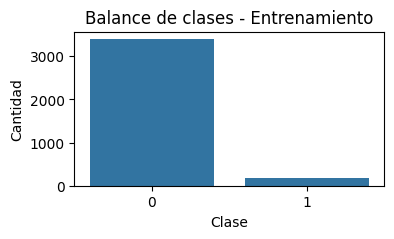

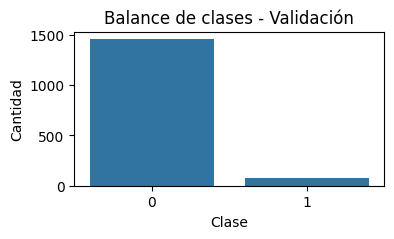

In [37]:
# Cargar datos procesados (usando joblib)
data = joblib.load('../data/processed_data.pkl')
X_train = data['X_train']
X_val = data['X_test']
y_train = data['y_train']
y_val = data['y_test']

print('X_train:', X_train.shape)
print('y_train:', y_train.shape)
print('X_val:', X_val.shape)
print('y_val:', y_val.shape)

# Balance de clases
def plot_class_balance(y, title):
    plt.figure(figsize=(4,2))
    sns.countplot(x=y)
    plt.title(title)
    plt.xlabel('Clase')
    plt.ylabel('Cantidad')
    plt.show()

plot_class_balance(y_train, 'Balance de clases - Entrenamiento')
plot_class_balance(y_val, 'Balance de clases - Validación')

## 2. Pipeline y búsqueda de hiperparámetros
Definimos un pipeline con escalado y SVM, y buscamos los mejores hiperparámetros con GridSearchCV usando validación cruzada estratificada y múltiples métricas.

## SVM training 

In [ ]:

# ------------------------------------------------------------
# 1. Métrica principal: F2-score
    # Beta = 2 => Recall pesa mucho más que Precision
# ------------------------------------------------------------
fscore = make_scorer(fbeta_score, beta=2)

# ------------------------------------------------------------
# 2. Validación cruzada estratificada
# ------------------------------------------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ------------------------------------------------------------
# 3. Pipeline base
# ------------------------------------------------------------
pipeline = Pipeline([
    ('model', SVC(
        random_state=42,
        probability=True,
        class_weight='balanced'
    ))
])

# ------------------------------------------------------------
# 4. Espacio de búsqueda combinado
# Incluye búsqueda inicial + búsqueda fina, todo junto
# ------------------------------------------------------------
param_distributions = [
    # Kernel lineal
    {
        "model__kernel": ["linear"],
        "model__C": np.unique(np.concatenate([
            [0.01, 0.1, 1, 10, 100],
            np.logspace(-3, 2, 7)
        ]))
    },
    
    # Kernel RBF
    {
        "model__kernel": ["rbf"],
        "model__C": np.unique(np.concatenate([
            [0.1, 1, 10, 100],
            np.logspace(-2, 2, 7)
        ])),
        "model__gamma": ["scale", "auto", 0.001, 0.005, 0.01, 0.05, 0.1]
    },
    
    # Kernel polinómico
    {
        "model__kernel": ["poly"],
        "model__C": [0.1, 1, 10],
        "model__degree": [2, 3, 4],
        "model__gamma": ["scale", "auto"]
    },
    
    # Kernel sigmoide
    {
        "model__kernel": ["sigmoid"],
        "model__C": [0.1, 1, 10],
        "model__gamma": ["scale", "auto"]
    }
]

# ------------------------------------------------------------
# 5. Métricas de evaluación
# F4 es la métrica principal para seleccionar el mejor modelo
# ------------------------------------------------------------
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "f2": fscore,
    "roc_auc": "roc_auc",
    "ap": "average_precision"
}

# ------------------------------------------------------------
# 6. Parámetros comunes del RandomizedSearchCV
# ------------------------------------------------------------
search_kwargs = dict(
    n_iter=30,                 # 30 combinaciones aleatorias
    scoring=scoring,
    refit="recall",                # refit según F4-score
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=1,
    return_train_score=False,
)

# ------------------------------------------------------------
# 7. Búsqueda aleatoria
# ------------------------------------------------------------
random_search_svm = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_distributions,
    **search_kwargs
)

random_search_svm.fit(X_train, y_train)


Fitting 5 folds for each of 30 candidates, totalling 150 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('model',
                                              SVC(class_weight='balanced',
                                                  probability=True,
                                                  random_state=42))]),
                   n_iter=30, n_jobs=-1,
                   param_distributions=[{'model__C': array([1.00000000e-03, 6.81292069e-03, 1.00000000e-02, 4.64158883e-02,
       1.00000000e-01, 3.16227766e-01, 1.00000000e+00, 2.1544...
                                         'model__gamma': ['scale', 'auto'],
                                         'model__kernel': ['poly']},
                                        {'model__C': [0.1, 1, 10],
                                         'model__gamma': ['scale', 'auto'],
                                         'model__kernel': ['sigmoid']}],
                   random_state=42, refit='recall',
                   scoring={'accuracy': 'accuracy', 'ap': 'average_precision',
                            'f1': 'f1',
                            'f4': make_scorer(fbeta_score, response_method='predict', beta=2),
                            'precision': 'precision', 'recall': 'recall',
                            'roc_auc': 'roc_auc'},
                   verbose=1)

In [39]:

# ------------------------------------------------------------
# 8. Resultados principales
# ------------------------------------------------------------
print("Mejores hiperparámetros:")
print(random_search_svm.best_params_)

print("\nMejor F2-score promedio en CV:")
print(f"{random_search_svm.best_score_:.4f}")

# ------------------------------------------------------------
# 9. Tabla resumen de resultados
# ------------------------------------------------------------
results_svm = pd.DataFrame(random_search_svm.cv_results_)

cols_to_show = [
    "params",
    "mean_test_accuracy",
    "mean_test_precision",
    "mean_test_recall",
    "mean_test_f1",
    "mean_test_f2",
    "mean_test_roc_auc",
    "mean_test_ap",
    "rank_test_f2"
]

summary_svm = (
    results_svm[cols_to_show]
    .sort_values("rank_test_f2")
    .reset_index(drop=True)
)

print("\nTop 10 configuraciones según F2-score:")
display(summary_svm.head(10))

# ------------------------------------------------------------
# 10. Mejor modelo final
# ------------------------------------------------------------
best_svm_model = random_search_svm.best_estimator_

Mejores hiperparámetros:
{'model__kernel': 'rbf', 'model__gamma': 0.01, 'model__C': 0.046415888336127774}

Mejor F4-score promedio en CV:
0.9195

Top 10 configuraciones según F4-score:


,params,mean_test_accuracy,mean_test_precision,mean_test_recall,mean_test_f1,mean_test_f4,mean_test_roc_auc,mean_test_ap,rank_test_f4
0,"{'model__kernel': 'poly', 'model__gamma': 'aut...",0.746639,0.138534,0.804706,0.236246,0.409772,0.836995,0.187071,1
1,"{'model__kernel': 'poly', 'model__gamma': 'aut...",0.789704,0.149825,0.707563,0.246859,0.404388,0.825534,0.171449,2
2,"{'model__kernel': 'poly', 'model__gamma': 'aut...",0.750275,0.137322,0.782017,0.233478,0.402848,0.839144,0.193053,3
3,"{'model__kernel': 'linear', 'model__C': 14.677...",0.727620,0.130806,0.810588,0.225131,0.397016,0.835158,0.190469,4
4,"{'model__kernel': 'rbf', 'model__gamma': 0.005...",0.718672,0.129022,0.827731,0.223140,0.396980,0.838561,0.194934,5
5,"{'model__kernel': 'linear', 'model__C': 100.0}",0.727620,0.130766,0.810588,0.225075,0.396953,0.835141,0.190729,6
6,"{'model__kernel': 'rbf', 'model__gamma': 0.01,...",0.716157,0.128291,0.833445,0.222275,0.396718,0.833326,0.181570,7
7,"{'model__kernel': 'linear', 'model__C': 0.1}",0.722306,0.129214,0.816303,0.222978,0.395125,0.837474,0.190561,8
8,"{'model__kernel': 'rbf', 'model__gamma': 0.001...",0.720069,0.128249,0.816303,0.221545,0.393337,0.838271,0.190978,9
9,"{'model__kernel': 'rbf', 'model__gamma': 0.005...",0.708326,0.125988,0.839160,0.219016,0.393331,0.840925,0.192513,10


### Training Bagging SVM

In [40]:

# ------------------------------------------------------------
# 2. Bagging sobre el mejor SVM encontrado
# ------------------------------------------------------------
# best_svm_model debe venir de la celda anterior:
# best_svm_model = random_search_svm.best_estimator_

bagging_svm = BaggingClassifier(
    estimator=clone(best_svm_model),
    n_estimators=15,
    max_samples=0.8,
    max_features=1.0,
    bootstrap=True,
    bootstrap_features=False,
    n_jobs=-1,
    random_state=42
)

bagging_svm.fit(X_train, y_train)



BaggingClassifier(estimator=Pipeline(steps=[('model',
                                             SVC(C=0.046415888336127774,
                                                 class_weight='balanced',
                                                 gamma=0.01, probability=True,
                                                 random_state=42))]),
                  max_samples=0.8, n_estimators=15, n_jobs=-1, random_state=42)

## Evaluacion de bagging SVC

=== VALIDACIÓN | BAGGING + SVM ===
Accuracy          : 0.9511
Precision         : 0.0000
Recall            : 0.0000
F1-score          : 0.0000
F4-score          : 0.0000
ROC-AUC           : 0.8346
Average Precision : 0.2196

Reporte de clasificación:
              precision    recall  f1-score   support

           0     0.9511    1.0000    0.9749      1458
           1     0.0000    0.0000    0.0000        75

    accuracy                         0.9511      1533
   macro avg     0.4755    0.5000    0.4875      1533
weighted avg     0.9045    0.9511    0.9272      1533



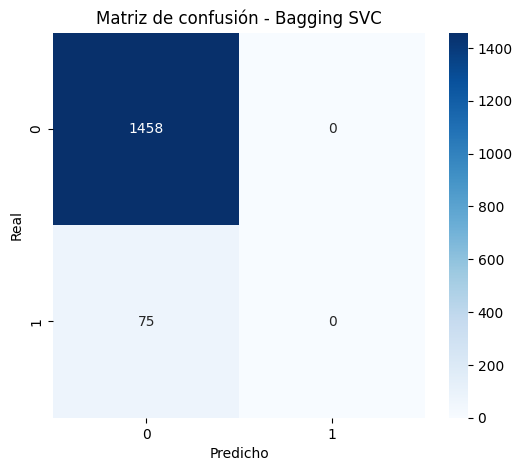

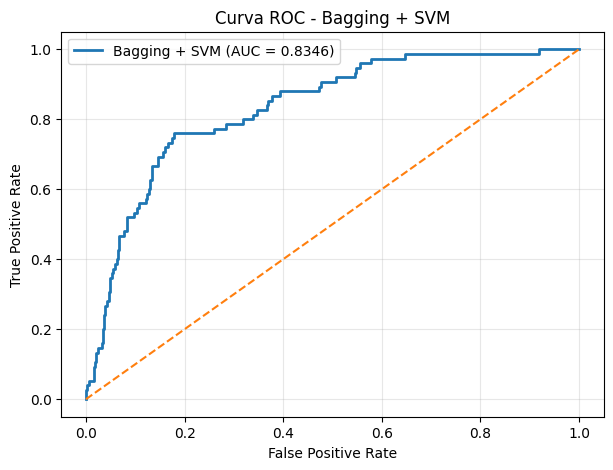

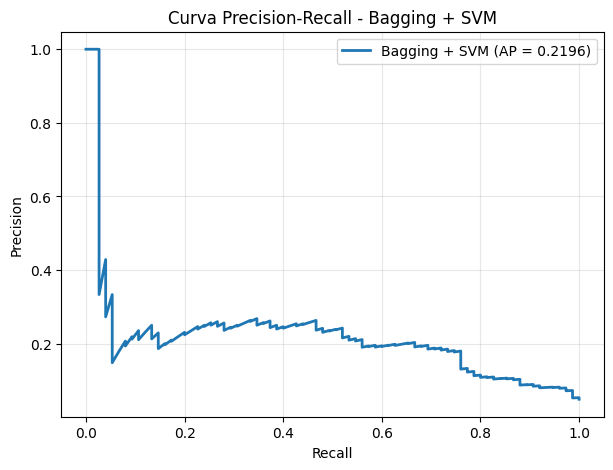

In [ ]:
# ------------------------------------------------------------
# 3. Evaluación en validación
# ------------------------------------------------------------
val_preds_bagging = bagging_svm.predict(X_val)
val_proba_bagging = bagging_svm.predict_proba(X_val)[:, 1]

f2_val_bagging = fbeta_score(y_val, val_preds_bagging, beta=2)

metrics_bagging = {
    "Accuracy": accuracy_score(y_val, val_preds_bagging),
    "Precision": precision_score(y_val, val_preds_bagging, zero_division=0),
    "Recall": recall_score(y_val, val_preds_bagging, zero_division=0),
    "F1-score": f1_score(y_val, val_preds_bagging, zero_division=0),
    "F2-score": f2_val_bagging,
    "ROC-AUC": roc_auc_score(y_val, val_proba_bagging),
    "Average Precision": average_precision_score(y_val, val_proba_bagging)
}

print("=== VALIDACIÓN | BAGGING + SVM ===")
for metric_name, metric_value in metrics_bagging.items():
    print(f"{metric_name:<18}: {metric_value:.4f}")

print("\nReporte de clasificación:")
print(classification_report(y_val, val_preds_bagging, digits=4, zero_division=0))

# ------------------------------------------------------------
# 4. Matriz de confusión
# ------------------------------------------------------------
cm_bagging = confusion_matrix(y_val, val_preds_bagging)


plt.figure(figsize=(6, 5))
sns.heatmap(cm_bagging, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de confusión - Bagging SVC")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.show()

# ------------------------------------------------------------
# 5. Curva ROC
# ------------------------------------------------------------
fpr_bagging, tpr_bagging, _ = roc_curve(y_val, val_proba_bagging)
roc_auc_bagging = roc_auc_score(y_val, val_proba_bagging)

plt.figure(figsize=(7, 5))
plt.plot(fpr_bagging, tpr_bagging, linewidth=2, label=f"Bagging + SVM (AUC = {roc_auc_bagging:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Bagging + SVM")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ------------------------------------------------------------
# 6. Curva Precision-Recall
# ------------------------------------------------------------
precision_bagging, recall_bagging, _ = precision_recall_curve(y_val, val_proba_bagging)
ap_bagging = average_precision_score(y_val, val_proba_bagging)

plt.figure(figsize=(7, 5))
plt.plot(recall_bagging, precision_bagging, linewidth=2, label=f"Bagging + SVM (AP = {ap_bagging:.4f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall - Bagging + SVM")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## Evaluacion de SVC

=== VALIDACIÓN | BAGGING + SVM ===
Accuracy          : 0.6197
Precision         : 0.1019
Recall            : 0.8667
F1-score          : 0.1823
F4-score          : 0.6012
ROC-AUC           : 0.8337
Average Precision : 0.2161

Reporte de clasificación:
              precision    recall  f1-score   support

           0     0.9888    0.6070    0.7522      1458
           1     0.1019    0.8667    0.1823        75

    accuracy                         0.6197      1533
   macro avg     0.5454    0.7368    0.4673      1533
weighted avg     0.9454    0.6197    0.7243      1533



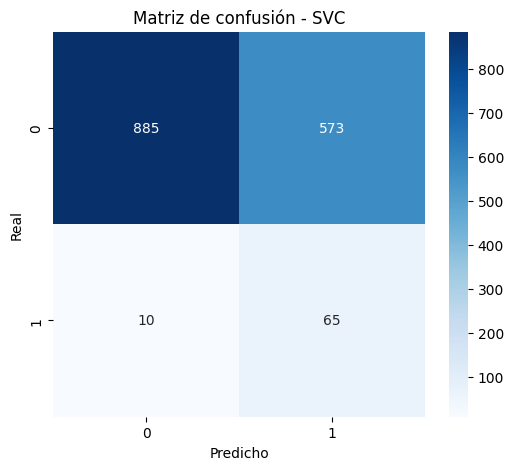

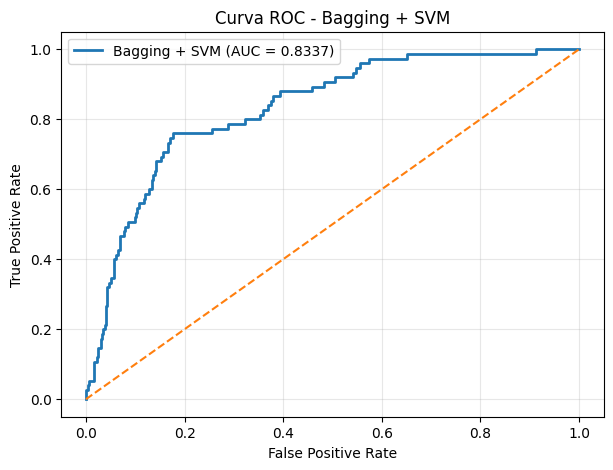

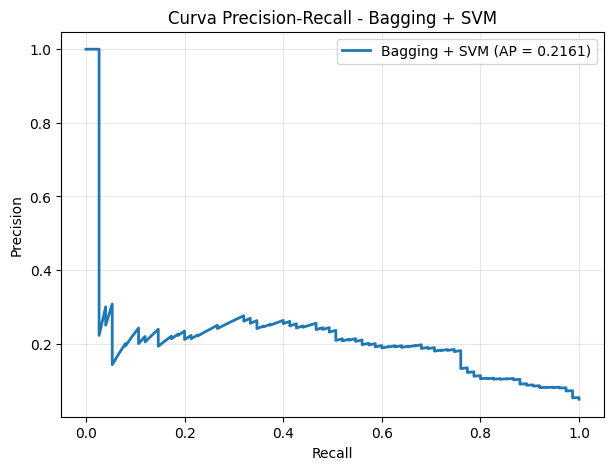


=== Comparación de modelos ===


,Modelo,Accuracy,Precision,Recall,F1-score,F4-score,ROC-AUC,Average Precision
0,SVM individual,0.6197,0.1019,0.8667,0.1823,0.6012,0.8337,0.2161
1,Bagging + SVM,0.9511,0.0000,0.0000,0.0000,0.0000,0.8346,0.2196


In [ ]:
# ------------------------------------------------------------
# 3. Evaluación en validación
# ------------------------------------------------------------
val_preds_svm = best_svm_model.predict(X_val)
val_proba_svm = best_svm_model.predict_proba(X_val)[:, 1]

f2_val_svm = fbeta_score(y_val, val_preds_svm, beta=2)

metrics_bagging = {
    "Accuracy": accuracy_score(y_val, val_preds_svm),
    "Precision": precision_score(y_val, val_preds_svm, zero_division=0),
    "Recall": recall_score(y_val, val_preds_svm, zero_division=0),
    "F1-score": f1_score(y_val, val_preds_svm, zero_division=0),
    "F2-score": f2_val_svm,
    "ROC-AUC": roc_auc_score(y_val, val_proba_svm),
    "Average Precision": average_precision_score(y_val, val_proba_svm)
}

print("=== VALIDACIÓN | BAGGING + SVM ===")
for metric_name, metric_value in metrics_bagging.items():
    print(f"{metric_name:<18}: {metric_value:.4f}")

print("\nReporte de clasificación:")
print(classification_report(y_val, val_preds_svm, digits=4, zero_division=0))

# ------------------------------------------------------------
# 4. Matriz de confusión
# ------------------------------------------------------------
cm_bagging = confusion_matrix(y_val, val_preds_svm)
cm_bagging_norm = cm_bagging.astype("float") / cm_bagging.sum(axis=1, keepdims=True)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_bagging, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de confusión - SVC")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.show()



# ------------------------------------------------------------
# 5. Curva ROC
# ------------------------------------------------------------
fpr_bagging, tpr_bagging, _ = roc_curve(y_val, val_proba_svm)
roc_auc_bagging = roc_auc_score(y_val, val_proba_svm)

plt.figure(figsize=(7, 5))
plt.plot(fpr_bagging, tpr_bagging, linewidth=2, label=f"Bagging + SVM (AUC = {roc_auc_bagging:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Bagging + SVM")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ------------------------------------------------------------
# 6. Curva Precision-Recall
# ------------------------------------------------------------
precision_bagging, recall_bagging, _ = precision_recall_curve(y_val, val_proba_svm)
ap_bagging = average_precision_score(y_val, val_proba_svm)

plt.figure(figsize=(7, 5))
plt.plot(recall_bagging, precision_bagging, linewidth=2, label=f"Bagging + SVM (AP = {ap_bagging:.4f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall - Bagging + SVM")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ------------------------------------------------------------
# 7. Comparación: SVM individual vs Bagging + SVM
# ------------------------------------------------------------
val_preds_svm = best_svm_model.predict(X_val)
val_proba_svm = best_svm_model.predict_proba(X_val)[:, 1]

comparison_df = pd.DataFrame([
    {
        "Modelo": "SVM individual",
        "Accuracy": accuracy_score(y_val, val_preds_svm),
        "Precision": precision_score(y_val, val_preds_svm, zero_division=0),
        "Recall": recall_score(y_val, val_preds_svm, zero_division=0),
        "F1-score": f1_score(y_val, val_preds_svm, zero_division=0),
        "F2-score": fbeta_score(y_val, val_preds_svm, beta=2),
        "ROC-AUC": roc_auc_score(y_val, val_proba_svm),
        "Average Precision": average_precision_score(y_val, val_proba_svm)
    },
    {
        "Modelo": "Bagging + SVM",
        "Accuracy": accuracy_score(y_val, val_preds_bagging),
        "Precision": precision_score(y_val, val_preds_bagging, zero_division=0),
        "Recall": recall_score(y_val, val_preds_bagging, zero_division=0),
        "F1-score": f1_score(y_val, val_preds_bagging, zero_division=0),
        "F2-score": fbeta_score(y_val, val_preds_bagging, beta=2),
        "ROC-AUC": roc_auc_score(y_val, val_proba_bagging),
        "Average Precision": average_precision_score(y_val, val_proba_bagging)
    }
])

print("\n=== Comparación de modelos ===")
display(
    comparison_df.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-score": "{:.4f}",
        "F2-score": "{:.4f}",
        "ROC-AUC": "{:.4f}",
        "Average Precision": "{:.4f}",
    })
)

